In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 필요에 따라 추후 WER도 계산하는거 구현해서 metric으로 사용해도 좋을듯

In [3]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [4]:
import editdistance


# def exprate_k(preds, targets, k=0, eos_idx=1):

#     # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

#     # preds: (B, T-1)
#     # targets: (B, T-1)

#     assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

#     cnt = 0
#     for pred_seq, tgt_seq in zip(preds, targets):

#         pred = pred_seq.tolist()
#         tgt = tgt_seq.tolist()

#         if eos_idx in pred:
#             pred = pred[:pred.index(eos_idx)]

#         if eos_idx in tgt:
#             tgt = tgt[:tgt.index(eos_idx)]

#         diff = editdistance.eval(pred, tgt)

#         if diff<=k:
#             cnt += 1

#     return cnt / preds.shape[0]


def exprate_k_revised(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    ignore_count = 0

    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        diff_lim = len(tgt)    # 거리오차는 target 길이보다 커질 수 없음

        if diff_lim <= k:    # 만약 거리오차 최댓값보다 같거나 더 큰 오차를 허용한다면 해당경우 무시 (무시하지 않을경우 의미 왜곡 발생하여 메트릭으로서의 기능상실)
            ignore_count += 1
            continue

        if diff<=k:
            cnt += 1

    if ignore_count==preds.shape[0]:
        is_ignore_all_batch = True
    else:
        is_ignore_all_batch = False

    return cnt / preds.shape[0], is_ignore_all_batch    # 만약 모든 배치에서 expr@k 계산하려고 할때 오차 최댓값이 k 이상이 되어 해당경우는 expr@k 메트릭으로 평가하면 메트릭으로서의 의미왜곡이 생길 수 있어 패스해야하는지 체크하는 인자를 함께 반한 (최종적으로 평균계산할때 이렇게 패스된 부분 고려해서 의미왜곡없이 평균 취해주기 위함)


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json


def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):
    """Loss 곡선 시각화."""

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1 (revised)", "expr@2 (revised)", "expr@3 (revised)", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)

In [7]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [25]:
import os, json
from datetime import datetime
import torch
from pathlib import Path

CFG = {
  "experiment_name": "dla_single_epoch100_bs16_scheduler_circularlrbeta_patience_100",
  "img_size": (128,768),
  "pad_idx": 112,
  "eos_idx": 1,

  "data": {
    "vocab": "data/vocab/crohme_vocab.txt",
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": 16,
    "epochs": 100,
    "learning_rate": 0.001,
    "match_weight": 0.2,
    "optimizer": "adamw",
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": 100,
  },

  "testing": {"max_len": 150},

  "paths":{
      "best_ckpt": "runs/(revised) dla_single_epoch50_bs16_scheduler_CosineAnnealingWarmupRestarts_patience_4/best_model.pth",
      "last_ckpt": "runs/(revised) dla_single_epoch50_bs16_scheduler_CosineAnnealingWarmupRestarts_patience_4/last_model.pth",
      "train_log_json": "runs/(revised) dla_single_epoch50_bs16_scheduler_CosineAnnealingWarmupRestarts_patience_4/train_log.json"
  }
}

CFG["paths"]["CFG"] = f"runs/{CFG['experiment_name']}/config.json"

scheduler_name = "circularlrbeta"
min_lr = 5e-4
max_lr = 5e-4

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

In [26]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/dla_single_epoch100_bs16_scheduler_circularlrbeta_patience_100/config.json


In [27]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset
- 변경사항: loader 부분에, 첫 에포크 때 학습 느리고 두번째 에포크부터 빨라지는 점 해결하기 위해 num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2 인자 추가

## Vocab

In [11]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [12]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [13]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [14]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

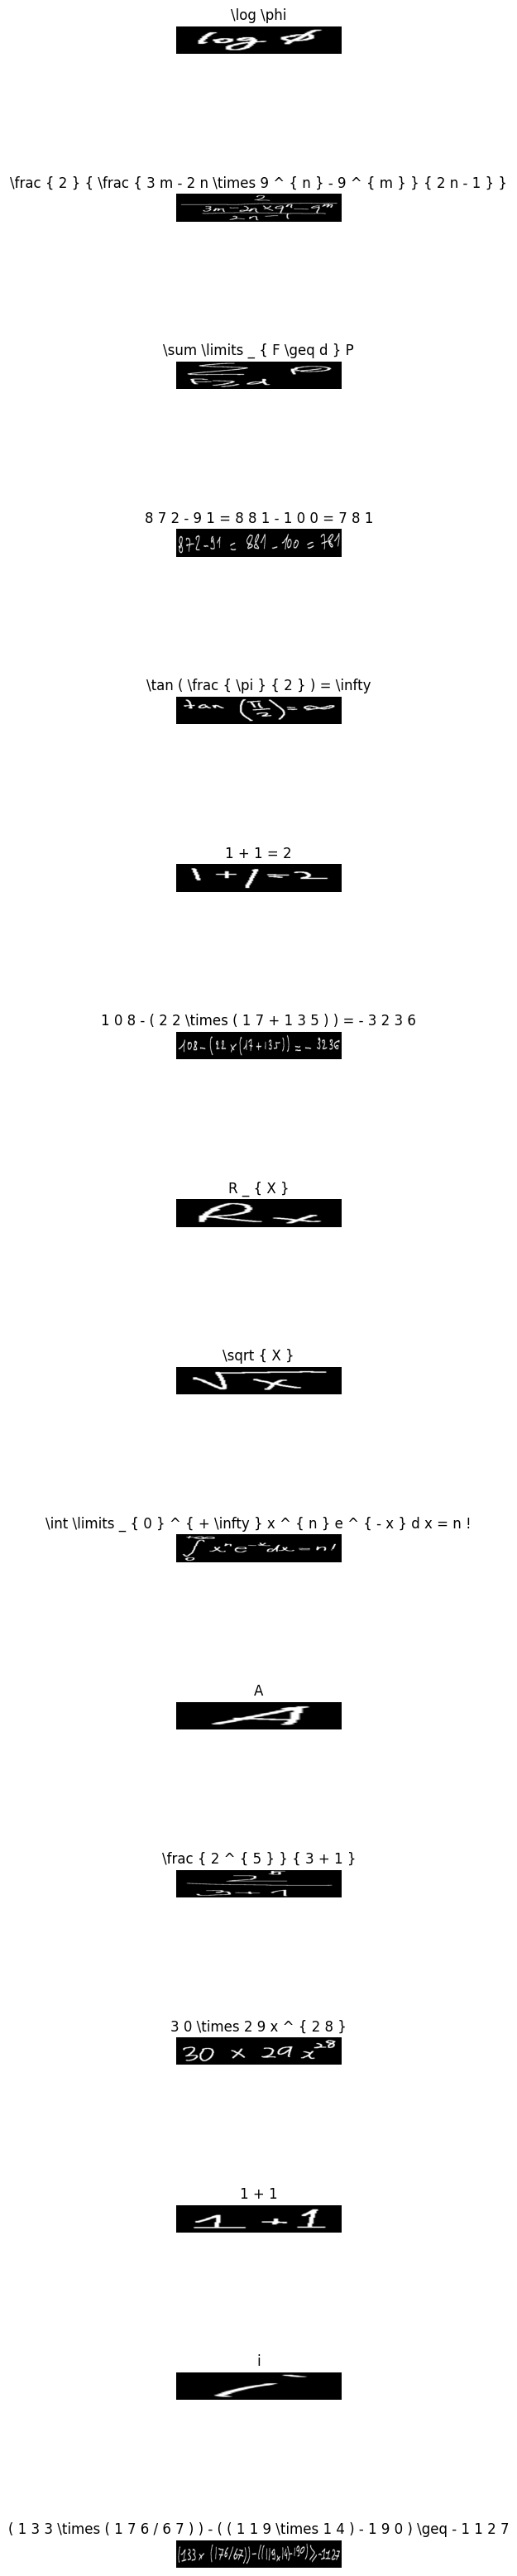

In [15]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=16, figure_width=1, figure_height=16, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## Encoder

In [16]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights


class DenseNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        densenet = densenet121(weights=None)    # 이번 프로젝트는 imageNet 데이터에 비교하면 수식글씨로, imageNet 가중치가 방해될 수도 있어 사전학습 가중치 없이 불러오는게 유리할수도 있음

        # First conv layer 수정: in_channels=1로 (우리 프로젝트에 맞춰 gpu 메모리 소모 줄이기 위해 그레이스케일로 변환)
        densenet.features.conv0 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove classification head
        features = list(densenet.features.children())

        # Use all layers except final norm+relu+avgpool
        self.backbone = nn.Sequential(*features[:-1])

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)                       # (B,1,128,768) -> (B,1024,4,24)
        B, D, _, _ = x.shape
        x = x.reshape(B, D, -1)                    # (B,1024,4*24)
        x = x.transpose(1,2)                       # (B,1024,96) -> (B,96,1024)
        return x


## Decoder

- 일단 단순성 편의상 num_layers는 nn.GRU에서 자동으로 반영하게 하였음, 그러나 이 경우 context 반영은 가장 초기 hidden cell에 대해서만 가능하고, 레이어별로 context 반영하는 등은 부족
- 만약 RNN 구조로 여러 층에서 context 반영하려면 nn.GRU 대신 nn.GRUCell 이용해서 수정하거나 nn.GRU에 (B,1,H) 대신 각 레이어 별 정보를 담아 (B,L,H)로 넘겨주면 되는듯. 그런데 그럴바에 차라리 셀프 어텐션으로 context 반영하게끔 하는 트랜스포머 구조로 만들어버리는게 나을수도?

In [17]:
import torch
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_dim_enc=1024, hidden_dim=256, emb_dim_dec=1024, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(emb_dim_enc+emb_dim_dec, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)


        # weight initialization

        # nn.GRU
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, prev_token, hidden, context):

        # prev_token: (B,D_dec)
        # hidden: (B,H)
        # context: (B,D_enc)

        # 지금은 num_layers는 무조건 1이라서 context는 (B,L,H) 대신 (B,1,H), hidden은 (D*L,B,H) 대신 (D,B,H)로 받는다고 생각하고 unsqueeze 등 shape 변경

        prev_token = prev_token.unsqueeze(1)                  # (B,D_dec) -> (B,1,D_dec)
        context = context.unsqueeze(1)                        # (B,D_enc) -> (B,1,D_enc)

        dec_input = torch.cat([prev_token, context], dim=-1)  # (B,1,D_dec+D_enc)

        # nn.GRU에서 요구하는 hidden 형상 (D*L,B,H)가 되도록 변경
        hidden = hidden.unsqueeze(0)

        output, hidden = self.gru(dec_input, hidden)
        output = output.squeeze(1)                       # (B,1,H) -> (B,H)
        hidden = hidden.squeeze(0)                       # (1,B,H) -> (B,H)

        output_logits = self.fc_out(output)             # (B,H) -> (B,V)
        return output_logits, hidden


## Cross Attention

### 변경사항
- 바다나우 어텐션 시 nn.Linear에서 bias=True, False 부분 조절
- 모델에 inference 함수 추가 => top-k, top-p, beam search 등 다양한 방식 inference 코드 작성해보기

In [18]:
# paired한 학습이 아니라 단일 도메인에 대해 돌렸을때 성능 나오는지 확인하기 위해 Paired 없을때 단일도메인 내 인코더-디코더 간 어텐션만 추가해서 구성한 Lite 모델

import torch.nn.functional as F
import random


# 디코더에서 패딩되어 들어오는 gt: (B,T)에서, pad를 제외한 실제 길이에 해당하는 length: (B,)를 구해서 pad부분은 tf 적용하지 않도록 할 떄 이용하는 함수
def get_lengths(labels, eos_id):

    # eos 위치 찾기 (없으면 전부 길이로)
    eos_mask = (labels == eos_id)
    # eos가 처음 등장하는 인덱스
    lengths = eos_mask.float().argmax(dim=1)

    # 만약 eos가 없는 경우 (argmax가 0을 반환) → 전체 길이로 처리
    lengths[lengths == 0] = labels.size(1)

    return lengths


class DLAModel_Lite(nn.Module):
    def __init__(self, model_config=None):
        super().__init__()

        # 설정 파라미터 추출
        self.vocab_size = model_config.get("vocab_size", 112)
        self.enc_emb_dim = model_config.get("encoder_emb_dim", 256)
        self.dec_emb_dim = model_config.get("decoder_emb_dim", 256)
        self.dec_hid_dim = model_config.get("decoder_hidden_dim", 512)

        self.embed = nn.Embedding(self.vocab_size, self.dec_emb_dim)

        # 인코더
        self.encoder = DenseNetEncoder()
        self.encoder_proj = nn.Linear(1024, self.enc_emb_dim)

        # 바다나우 어텐션 위한 파라미터
        self.W_enc = nn.Linear(self.enc_emb_dim, self.dec_hid_dim, bias=False)
        self.W_hidden = nn.Linear(self.dec_hid_dim, self.dec_hid_dim, bias=True)
        self.v = nn.Linear(self.dec_hid_dim, 1, bias=False)

        # 디코더
        self.decoder = Decoder(self.vocab_size, self.enc_emb_dim, self.dec_hid_dim, self.dec_emb_dim)


        # weight initialization

        # 임베딩 레이어
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, images, labels, tf_ratio=CFG["training"]["tf_ratio"]):

        # images: (B,1,128,768)
        # labels: (B,T)

        enc = self.encoder(images)     # (B,96,1024)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        T = labels.shape[1]            # max_seq_len => <sos>, <eos> 포함

        # HME 디코딩
        dec_out = []

        # <sos>
        prev_token = labels[:, 0]             # (B,) - <sos>
        prev_token = self.embed(prev_token)   # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)

        length = get_lengths(labels, eos_id=CFG["eos_idx"]) # (B,)

        for t in range(1,T):

            scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)
            scores = self.v(scores).squeeze(2)         # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)     # (B,96)

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            tf_mask = torch.rand(B, device=images.device) < tf_ratio  # (B,)
            valid_mask = t < length                                   # (B,)
            final_mask = tf_mask & valid_mask                         # (B,)

            # 기본값은 모델 예측 argmax
            prev_token = logits_y.argmax(dim=-1)

            # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
            prev_token[final_mask] = labels[final_mask, t]

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out


    def inference(self, images, max_seq_len):

        # images: (B,1,128,768)

        enc = self.encoder(images)     # (B,96,D_enc)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        # PME 디코딩
        dec_out = []

        # <sos>
        prev_token = torch.zeros(B, dtype=torch.long, device=images.device)         # (B,) - <sos>
        prev_token = self.embed(prev_token)                                        # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)


        for t in range(1,max_seq_len):

            scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)
            scores = self.v(scores).squeeze(2)        # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)   # (B,96)

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc) == (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            # inference 시점이므로 teacher forcing 적용하지 않음
            prev_token = logits_y.argmax(dim=-1)  # (B,V) -> (B,)

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out

# Train

In [19]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            num_ignore_for_expr1 = 0
            num_ignore_for_expr2 = 0
            num_ignore_for_expr3 = 0

            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels)              # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                if ignore_flag_expr1==False:
                    total_expr_1 += float(expr_1)
                else:
                    expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr2==False:
                    total_expr_2 += float(expr_2)
                else:
                    expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr3==False:
                    total_expr_3 += float(expr_3)
                else:
                    expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                total_wer += float(wer)

                if ignore_flag_expr1:
                    num_ignore_for_expr1 += 1

                if ignore_flag_expr2:
                    num_ignore_for_expr2 += 1

                if ignore_flag_expr3:
                    num_ignore_for_expr3 += 1

                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
            avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
            avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
            # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            num_ignore_for_expr1 = 0
            num_ignore_for_expr2 = 0
            num_ignore_for_expr3 = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                if ignore_flag_expr1==False:
                    total_expr_1 += float(expr_1)
                else:
                    expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr2==False:
                    total_expr_2 += float(expr_2)
                else:
                    expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                if ignore_flag_expr3==False:
                    total_expr_3 += float(expr_3)
                else:
                    expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

                total_wer += float(wer)

                if ignore_flag_expr1:
                    num_ignore_for_expr1 += 1

                if ignore_flag_expr2:
                    num_ignore_for_expr2 += 1

                if ignore_flag_expr3:
                    num_ignore_for_expr3 += 1

                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
            avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
            avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
            # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [20]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0

        num_ignore_for_expr1 = 0
        num_ignore_for_expr2 = 0
        num_ignore_for_expr3 = 0

        lr_history = []

        loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:
            optimizer.zero_grad()

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels)              # (B,T-1,V)
            labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

            loss.backward()

            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

            with torch.no_grad():
                expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            if ignore_flag_expr1==False:
                total_expr_1 += float(expr_1)
            else:
                expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            if ignore_flag_expr2==False:
                total_expr_2 += float(expr_2)
            else:
                expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            if ignore_flag_expr3==False:
                total_expr_3 += float(expr_3)
            else:
                expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            total_wer += float(wer)

            if ignore_flag_expr1:
                num_ignore_for_expr1 += 1

            if ignore_flag_expr2:
                num_ignore_for_expr2 += 1

            if ignore_flag_expr3:
                num_ignore_for_expr3 += 1

            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

            if scheduler is not None:
                scheduler.step()

            lr_history.append(optimizer.param_groups[0]['lr'])

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
        avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
        avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
        # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
        avg_wer = total_wer / num_batches


        print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Train"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer,
            "lr": lr_history
        })

        # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
        # if scheduler:
        #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        #         scheduler.step(avg_loss)
        #     else:
        #         scheduler.step()



        # validation
        model.eval()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0

        num_ignore_for_expr1 = 0
        num_ignore_for_expr2 = 0
        num_ignore_for_expr3 = 0

        loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels)
            labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

            expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
            expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
            expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
            expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
            wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            if ignore_flag_expr1==False:
                total_expr_1 += float(expr_1)
            else:
                expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            if ignore_flag_expr2==False:
                total_expr_2 += float(expr_2)
            else:
                expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            if ignore_flag_expr3==False:
                total_expr_3 += float(expr_3)
            else:
                expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

            total_wer += float(wer)

            if ignore_flag_expr1:
                num_ignore_for_expr1 += 1

            if ignore_flag_expr2:
                num_ignore_for_expr2 += 1

            if ignore_flag_expr3:
                num_ignore_for_expr3 += 1

            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
        avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
        avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
        # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 우리가 사용하는 학습데이터셋은 그런경우가 없음을 알기에 따로 해당경우 처리하는 부분을 따로 마련해주지 않았음
        avg_wer = total_wer / num_batches


        print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Valid"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer
        })

        torch.save({"model": model.state_dict()}, save_last)

        if epoch == 1 or avg_loss < best_loss:
            best_loss = avg_loss
            patience = 0
            save_best.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict()}, save_best)
            print("Best model saved.")

        else:
            patience += 1
            print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
            if patience >= CFG["training"]["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

        print()


    return log_dict, best_loss

In [21]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [22]:
# CosineAnnealingWarmupRestart 커스텀 클래스

import math
from torch.optim.lr_scheduler import _LRScheduler

class CosineAnnealingWarmupRestarts(_LRScheduler):

    def __init__(self,
                 optimizer: torch.optim.Optimizer,
                 first_cycle_steps: int,
                 cycle_mult: float = 1.,
                 max_lr: float = 0.1,
                 min_lr: float = 0.0001,
                 warmup_steps: int = 0,
                 gamma: float = 1.,
                 last_epoch: int = -1):
        assert warmup_steps < first_cycle_steps

        self.first_cycle_steps = first_cycle_steps
        self.cycle_mult = cycle_mult
        self.base_max_lr = max_lr
        # self.max_lr = max_lr
        self.min_lr = min_lr
        self.warmup_steps = warmup_steps
        self.gamma = gamma

        self.cur_cycle_steps = first_cycle_steps
        self.cycle = 0
        self.step_in_cycle = last_epoch

        super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

        self.init_lr()

    def init_lr(self):
        self.base_lrs = []
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.min_lr
            self.base_lrs.append(self.min_lr)

    def get_lr(self):
        if self.step_in_cycle == -1:
            return self.base_lrs
        elif self.step_in_cycle < self.warmup_steps:
            return [(self.max_lr - base_lr) * self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
        else:
            return [base_lr + (self.max_lr - base_lr) \
                    * (1 + math.cos(math.pi * (self.step_in_cycle - self.warmup_steps) / (self.cur_cycle_steps - self.warmup_steps))) / 2
                    for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
            self.step_in_cycle = self.step_in_cycle + 1
            if self.step_in_cycle >= self.cur_cycle_steps:
                self.cycle += 1
                self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
                self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps

        else:
            if epoch >= self.first_cycle_steps:
                if self.cycle_mult == 1.:
                    self.step_in_cycle = epoch % self.first_cycle_steps
                    self.cycle = epoch // self.first_cycle_steps
                else:
                    n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
                    self.cycle = n
                    self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
                    self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)

            else:
                self.cur_cycle_steps = self.first_cycle_steps
                self.step_in_cycle = epoch

        self.max_lr = self.base_max_lr * (self.gamma ** self.cycle)
        self.last_epoch = math.floor(epoch)
        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

In [29]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*CFG["training"]["epochs"],  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*CFG["training"]["epochs"]*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [ ]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

In [ ]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = DLAModel_Lite(model_config=CFG["model"]).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/100: 100%|██████████| 442/442 [1:27:04<00:00, 11.82s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.06, lr=6e-5, wer=1.35]



[Train Epoch 1] Loss: 3.3025, Expr@0: 0.0000, Expr@1: 0.0007, Expr@2: 0.0047, Expr@3: 0.0156, WER: 1.8786


[Valid] Epoch 1/100: 100%|██████████| 1767/1767 [22:21<00:00,  1.32it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.83, wer=0.756]



[Valid Epoch 1] Loss: 3.1853, Expr@0: 0.0017, Expr@1: 0.0078, Expr@2: 0.0225, Expr@3: 0.0514, WER: 0.8197
Best model saved.



[Train] Epoch 2/100: 100%|██████████| 442/442 [02:24<00:00,  3.07it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.75, lr=7e-5, wer=0.697]


...


[Valid Epoch 99] Loss: 0.7988, Expr@0: 0.5846, Expr@1: 0.7215, Expr@2: 0.7917, Expr@3: 0.8215, WER: 0.1342
Early Stopping count: 15/100



[Train] Epoch 100/100: 100%|██████████| 442/442 [02:23<00:00,  3.07it/s, expr0=1, expr1=0.909, expr2=0.909, expr3=0.818, loss=0.000117, lr=5.22e-7, wer=0]



[Train Epoch 100] Loss: 0.0002, Expr@0: 1.0000, Expr@1: 0.9466, Expr@2: 0.9141, Expr@3: 0.8612, WER: 0.0000


[Valid] Epoch 100/100: 100%|██████████| 1767/1767 [01:21<00:00, 21.65it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.36, wer=0.4]



[Valid Epoch 100] Loss: 0.8016, Expr@0: 0.5863, Expr@1: 0.7221, Expr@2: 0.7899, Expr@3: 0.8215, WER: 0.1343
Early Stopping count: 16/100



In [ ]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/(revised) dla_single_epoch50_bs16_scheduler_CosineAnnealingWarmupRestarts_patience_4/train_log.json


In [ ]:
!pip install torchinfo -q
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                        Param #
DLAModel_Lite                                 --
├─Embedding: 1-1                              28,672
├─DenseNetEncoder: 1-2                        --
│    └─Sequential: 2-1                        --
│    │    └─Conv2d: 3-1                       3,136
│    │    └─BatchNorm2d: 3-2                  128
│    │    └─ReLU: 3-3                         --
│    │    └─MaxPool2d: 3-4                    --
│    │    └─_DenseBlock: 3-5                  335,040
│    │    └─_Transition: 3-6                  33,280
│    │    └─_DenseBlock: 3-7                  919,680
│    │    └─_Transition: 3-8                  132,096
│    │    └─_DenseBlock: 3-9                  2,837,760
│    │    └─_Transition: 3-10                 526,336
│    │    └─_DenseBlock: 3-11                 2,158,080
├─Linear: 1-3                                 262,400
├─Linear: 1-4                                 131,072
├─Linear: 1-5                                 262,656
├─L

In [ ]:
!pip install torchview -q
from torchview import draw_graph

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

graph = draw_graph(model, input_data=(images, labels))
display(graph.visual_graph)

In [ ]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

In [ ]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

In [ ]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

In [ ]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

In [ ]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

In [ ]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

In [ ]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

In [ ]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

In [ ]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    num_ignore_for_expr1 = 0
    num_ignore_for_expr2 = 0
    num_ignore_for_expr3 = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0, _ = exprate_k_revised(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
        expr_1, ignore_flag_expr1 = exprate_k_revised(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
        expr_2, ignore_flag_expr2 = exprate_k_revised(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
        expr_3, ignore_flag_expr3 = exprate_k_revised(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
        wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

        total_loss += float(loss.item())
        total_expr_0 += float(expr_0)
        if ignore_flag_expr1==False:
            total_expr_1 += float(expr_1)
        else:
            expr_1 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        if ignore_flag_expr2==False:
            total_expr_2 += float(expr_2)
        else:
            expr_2 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        if ignore_flag_expr3==False:
            total_expr_3 += float(expr_3)
        else:
            expr_3 = None    # 사실상 이때는 값을 저장 안해도 되지만, tqdm에 표시해주기 위해 추가하였음

        total_wer += float(wer)

        if ignore_flag_expr1:
            num_ignore_for_expr1 += 1

        if ignore_flag_expr2:
            num_ignore_for_expr2 += 1

        if ignore_flag_expr3:
            num_ignore_for_expr3 += 1

        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / (num_batches - num_ignore_for_expr1)
    avg_expr_2 = total_expr_2 / (num_batches - num_ignore_for_expr2)
    avg_expr_3 = total_expr_3 / (num_batches - num_ignore_for_expr3)
    # 사실 (num_batches - num_ignore_for_expr@k) 계산 시, 만약 데이터셋 전체에서 정답 토큰의 길이가 k이하라면 이때는 num_batches == num_ignore_for_expr@k 가 되어 zero division error가 뜰 수 있어 이 경우 방지위해 처리를 해주어야하지만, 테스트데이터셋의 크기를 고려할 때 해당경우 없다고 가정해서 처리하는 부분을 따로 마련해주지 않았음
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [ ]:
# best_model.pth 가져오기

model = DLAModel_Lite(model_config=CFG["model"]).to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1 (revised)": [],
            "expr@2 (revised)": [],
            "expr@3 (revised)": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    print(f"Loss: {loss:.4f}, Expr@0: {expr0:.4f}, Expr@1: {expr1:.4f}, Expr@2: {expr2:.4f}, Expr@3: {expr3:.4f}, WER: {wer:.4f}")

    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1 (revised)"].append(expr1)
    val_dict["expr@2 (revised)"].append(expr2)
    val_dict["expr@3 (revised)"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

# Prediction 샘플 시각화

수정사항:
- im2latex test데이터의 경우 crop 및 투명도제거 전처리 안되어있는 것 확인해서 전처리해서 따로 저장해주었음

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

## 디버깅

- exprate 계산 시, 단순히 @k로 해버리면 우연히 토큰길이가 k보다 작으면 아예 예측을 이상하게 해도 맞다고 처리해버리는 문제 발견 => 이 부분 개선하도록 메트릭 수정 및 캐글이나 네이버부스트코스  자료 등 코드에는 이 부분 처리하도록 되어있는지 확인할 것
- 논문에서처럼 학습의 어떤 부분이 이미지의 어떤 부분을 참고하고 있는지 시각화해서 xAI방법에서 디버깅해보기 -> 잘 학습되고 있는지,,, (WAP 논문 시각화를 직접 해보는 느낌)
- 128*768로 resize해서 시작 안하고 128x128에서부터 시작해보기? (지푸라기라도 잡는 심정)
- 어떻게 추가할지는 모르겠지만,정칙화 텀을 추가해보기?
- 그래도 안되면 기본 방법은 어느정도 예측 잘할때까지 학습하려면 기본적으로 에포크 너무많이 필요해서 그런거라고 생각하고 트랜스포머 기반으로 바로 적용 시도하는걸로 넘어가기, 트랜스포머 기반으로 두 도메인 이용할 수 있도록 고민해보기)
- dla나 wap에서 어텐션 이외에 추가적으로 도입했던, 내가 구현할때 미처 반영하지 못한 부분 있으면 반영해서 다시 수정해보기

# Next Step
- Densenet 내부 구현 디테일 공부해보기 -> WAP, DLA, PAL논문 읽으며 인코더 디테일 구조 다시한번 체크해보기
- beamsearch, top-k, top-p 등 다른 디코딩 (inference) 방법 적용
- 현재 service account api 토큰 때문에 github private로 해둠 -> service account api를 env등으로 암호화 및 gitignore에 추가한 후 public으로 github 폴더 visibility 변경해두기

<br><br>
- 옵션
    - 바다나우 어텐션 대신 루옹 어텐션 적용 (소연 코드 참고)
